Step 1: Upload Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving car data.csv to car data.csv


Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression

plt.style.use('ggplot')

Step 3: Load Dataset

In [3]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Step 4: Basic Information

In [4]:
print(df.shape)

df.info()

df.describe()

(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Step 5: Check Missing Values

In [5]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


Step 6: Dataset Overview

In [6]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

Step 7: Create Car Age Feature

In [7]:
df['Car_Age'] = 2026 - df['Year']

df.drop('Year', axis=1, inplace=True)

df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


Step 8: Visualize Selling Price Distribution

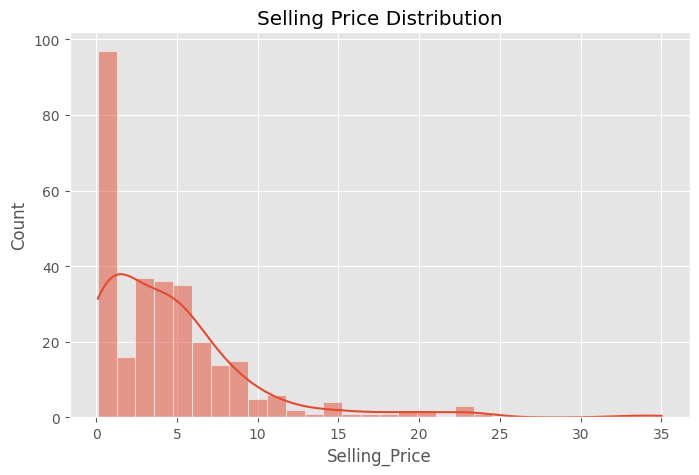

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Selling_Price'],
             bins=30,
             kde=True)

plt.title("Selling Price Distribution")

plt.show()

Step 9: Correlation Heatmap

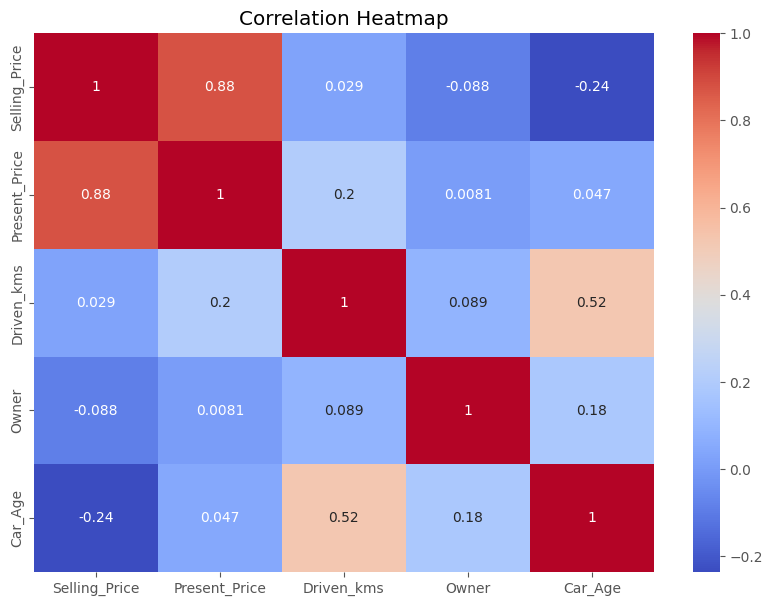

In [9]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Step 10: Fuel Type Analysis

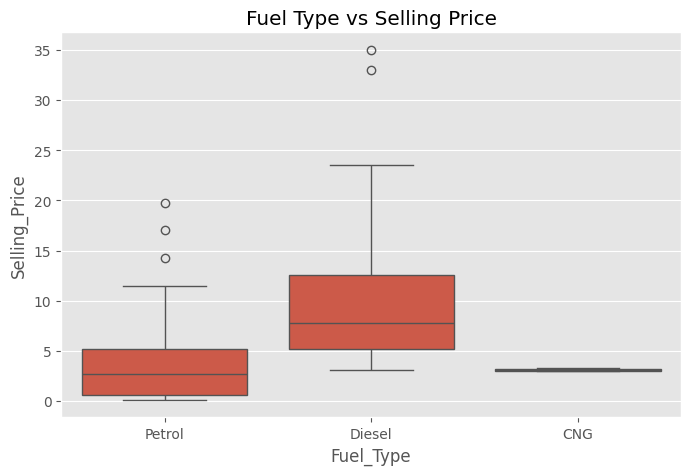

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Fuel_Type',
    y='Selling_Price',
    data=df
)

plt.title("Fuel Type vs Selling Price")

plt.show()

Step 11: Transmission Analysis

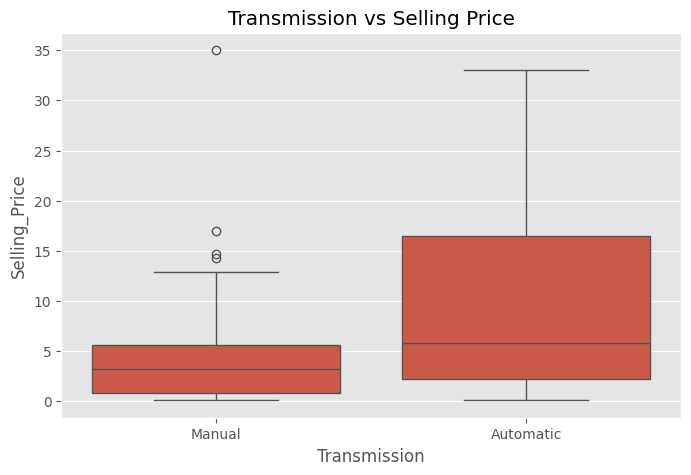

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Transmission',
    y='Selling_Price',
    data=df
)

plt.title("Transmission vs Selling Price")

plt.show()

Step 12: Present Price vs Selling Price

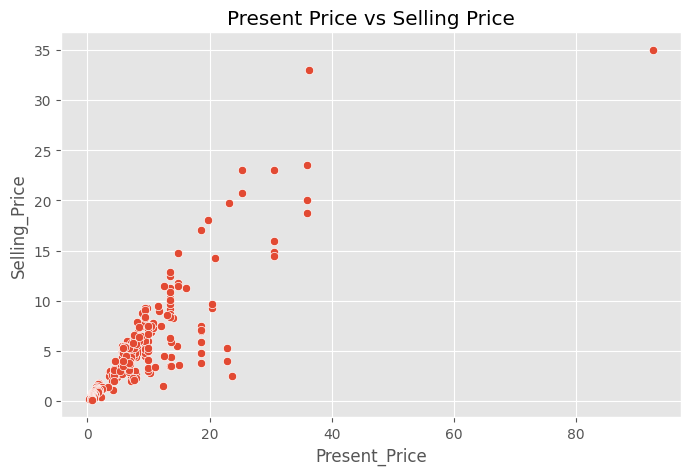

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Present_Price',
    y='Selling_Price',
    data=df
)

plt.title("Present Price vs Selling Price")

plt.show()

Step 13: Encode Categorical Features

In [14]:
le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])

df['Selling_type'] = le.fit_transform(df['Selling_type'])

df['Transmission'] = le.fit_transform(df['Transmission'])

df['Car_Name'] = le.fit_transform(df['Car_Name'])

Step 14: Prepare Features and Target

In [15]:
X = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']

Step 15: Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 16: Train Model

In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Step 17: Prediction

In [18]:
y_pred = model.predict(X_test)

Step 18: Model Evaluation

In [19]:
print("MAE :", mean_absolute_error(y_test,y_pred))

print("MSE :", mean_squared_error(y_test,y_pred))

print("R2 Score :", r2_score(y_test,y_pred))

MAE : 1.2147329896533692
MSE : 3.5370204237410316
R2 Score : 0.846454062382244


Step 19: Actual vs Predicted Graph

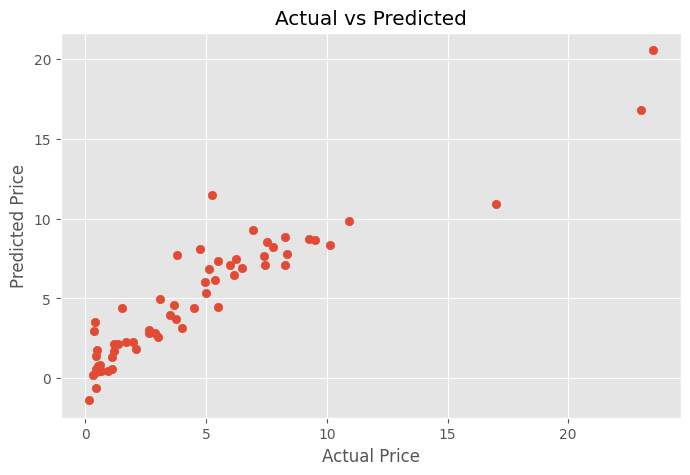

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

Step 20: Feature Importance

In [21]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':model.coef_
})

importance.sort_values(
    by='Coefficient',
    ascending=False,
    inplace=True
)

importance

,Feature,Coefficient
1,Present_Price,0.440443
2,Driven_kms,-0.000006
0,Car_Name,-0.003143
7,Car_Age,-0.361160
6,Owner,-0.911339
4,Selling_type,-1.301768
3,Fuel_Type,-1.339365
5,Transmission,-1.640356


Step 21: Predict New Car Price

In [22]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Selling Price =", prediction[0])

Predicted Selling Price = 3.9195651707027928


Step 22: Save Model

In [23]:
import joblib

joblib.dump(model,"car_price_prediction_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
